## EDA

### Problem Context

# Apple Stock Price Forecasting (EDA)

## Objective
Understand historical behavior of Apple stock prices (2012–2019) to inform model design for 30-day forecasting.

## What we analyze
- Trend (long-term movement)
- Seasonality (repeating patterns)
- Volatility (risk / fluctuations)
- Distribution (statistical properties)
- Relationships between variables

### Import Libraries

In [1]:
# Data manipulation
import pandas as pd               # for structured data operations
import numpy as np                # for numerical computations

# Visualization
import matplotlib.pyplot as plt   # base plotting
import seaborn as sns             # advanced statistical plots

# Time-series decomposition
from statsmodels.tsa.seasonal import seasonal_decompose  # to split into trend/seasonal/residual

### Load & Prepare Data

In [2]:


# Load CSV into DataFrame
df = pd.read_csv("P668 DATASET.csv")

# Convert 'Date' column to datetime type (required for time series)
df['Date'] = pd.to_datetime(df['Date'])

# Set Date as index so plots/models treat it as time axis
df.set_index('Date', inplace=True)

# Ensure chronological order (very important for time series)
df = df.sort_index()

# Handle missing values using forward fill (use previous valid value)
df = df.ffill()

# Quick preview
df.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2012-01-03,58.485714,58.928570,58.428570,58.747143,50.765709,75555200
2012-01-04,58.571430,59.240002,58.468571,59.062859,51.038536,65005500
2012-01-05,59.278572,59.792858,58.952858,59.718571,51.605175,67817400
2012-01-06,59.967144,60.392857,59.888573,60.342857,52.144630,79573200
2012-01-09,60.785713,61.107143,60.192856,60.247143,52.061932,98506100


### Basic Structure

In [3]:
# Check data types, missing values
df.info()

# Statistical summary (mean, std, min, max)
df.describe()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2011 entries, 2012-01-03 to 2019-12-30
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       2011 non-null   float64
 1   High       2011 non-null   float64
 2   Low        2011 non-null   float64
 3   Close      2011 non-null   float64
 4   Adj Close  2011 non-null   float64
 5   Volume     2011 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 110.0 KB


,Open,High,Low,Close,Adj Close,Volume
count,2011.000000,2011.000000,2011.000000,2011.000000,2011.000000,2.011000e+03
mean,126.707469,127.827594,125.580258,126.741235,119.505548,5.949670e+07
std,50.483753,50.926301,50.124940,50.578369,52.438444,4.683856e+07
min,55.424286,57.085712,55.014286,55.790001,48.921928,1.136200e+07
25%,85.882858,86.717858,85.056427,86.202145,75.056679,2.758565e+07
50%,113.050003,114.190002,111.870003,113.050003,105.222908,4.346900e+07
75%,165.190002,167.409996,163.424995,165.245002,160.047111,7.471030e+07
max,291.119995,293.970001,288.119995,291.519989,289.522614,3.765300e+08


### Trend Analysis

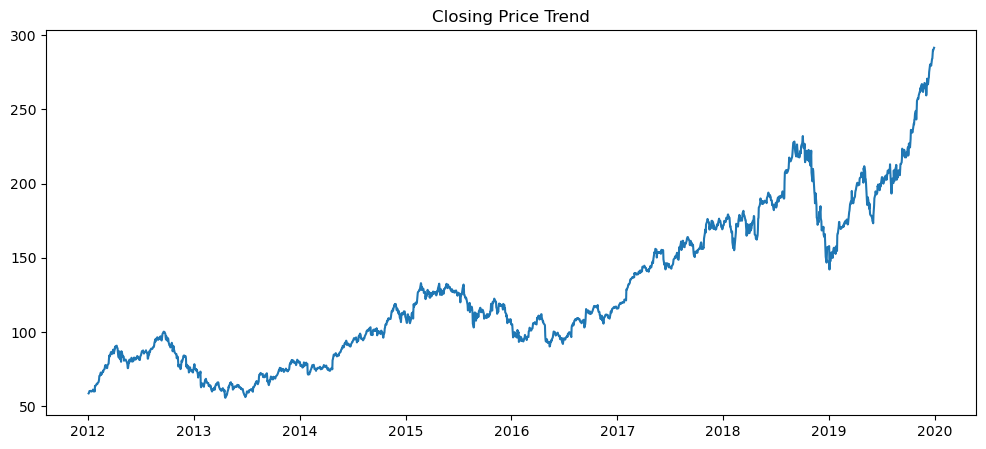

In [4]:
plt.figure(figsize=(12,5))
plt.plot(df['Close'])
plt.title("Closing Price Trend")
plt.show()

* Shows long-term upward trend
* Indicates non-stationarity (important for ARIMA)* 

### Moving Averages (Short vs Long Term)

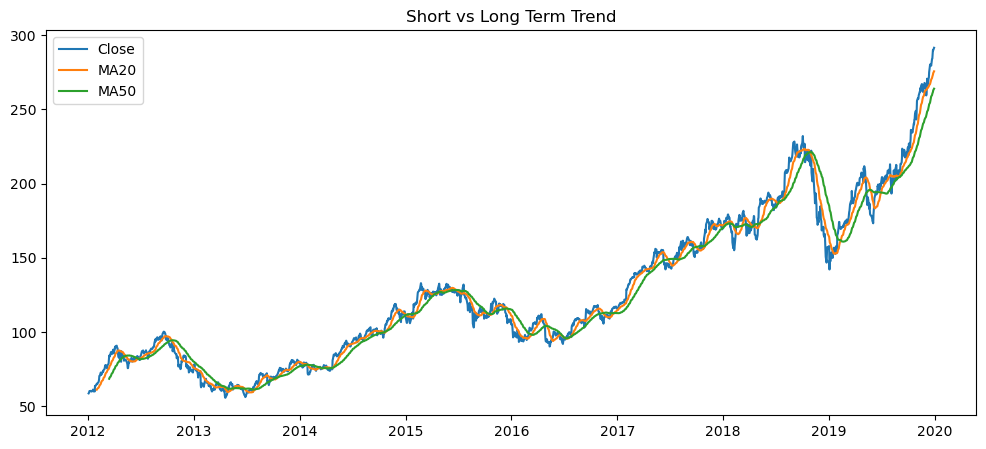

In [5]:
df['MA20'] = df['Close'].rolling(20).mean()
df['MA50'] = df['Close'].rolling(50).mean()

plt.figure(figsize=(12,5))
plt.plot(df['Close'], label='Close')
plt.plot(df['MA20'], label='MA20')
plt.plot(df['MA50'], label='MA50')

plt.legend()
plt.title("Short vs Long Term Trend")
plt.show()

* MA20 reacts faster → short-term changes
* MA50 smoother → long-term trend

### Volatility Analysis

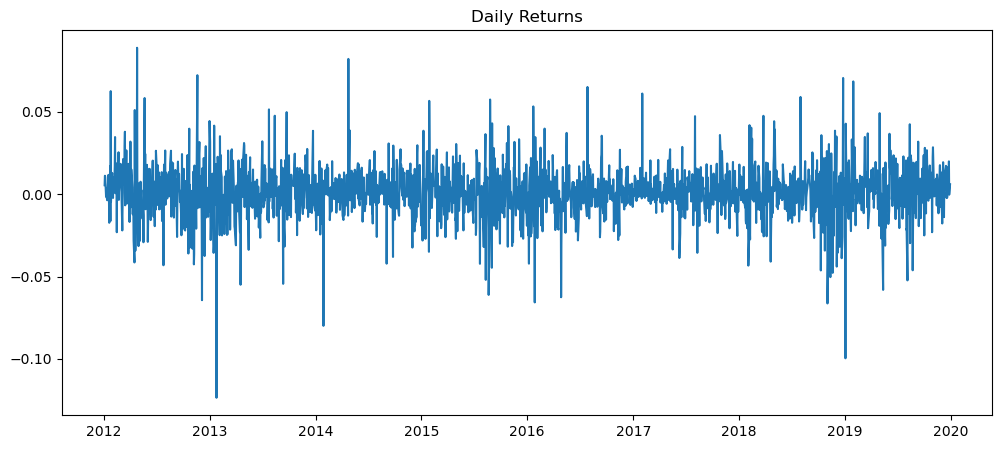

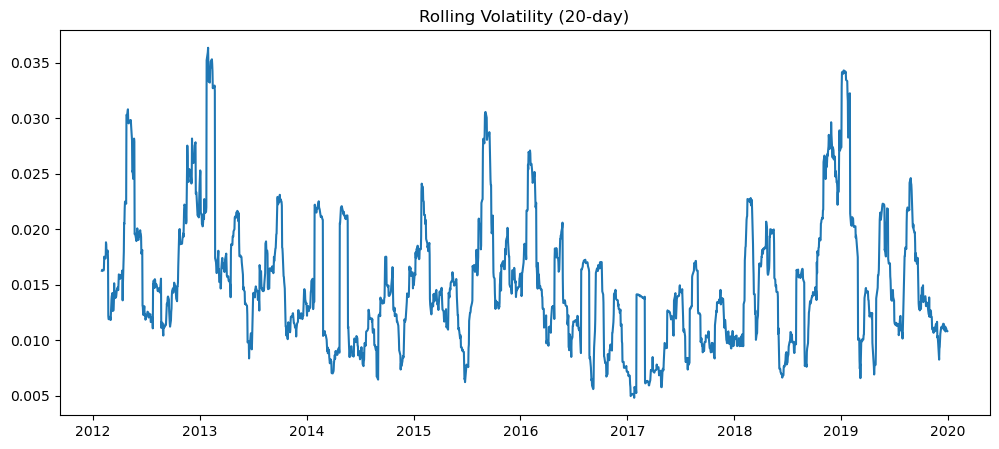

In [6]:
# Calculate daily returns (percentage change)
df['returns'] = df['Close'].pct_change()

# Rolling volatility (risk)
df['volatility'] = df['returns'].rolling(20).std()

# Plot returns
plt.figure(figsize=(12,5))
plt.plot(df['returns'])
plt.title("Daily Returns")
plt.show()

# Plot volatility
plt.figure(figsize=(12,5))
plt.plot(df['volatility'])
plt.title("Rolling Volatility (20-day)")
plt.show()

* Returns → short-term fluctuations
* Volatility → risk level over time

### Distribution & Outliers

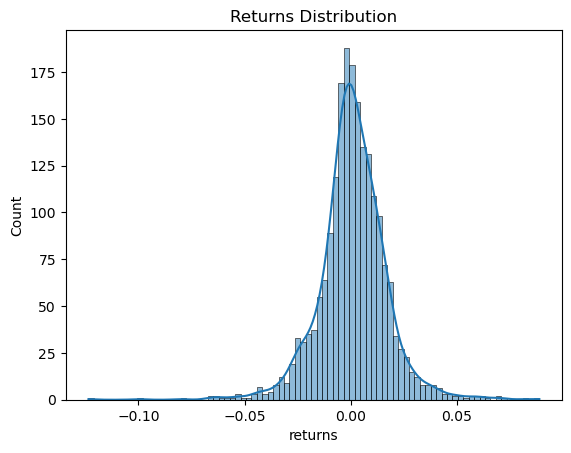

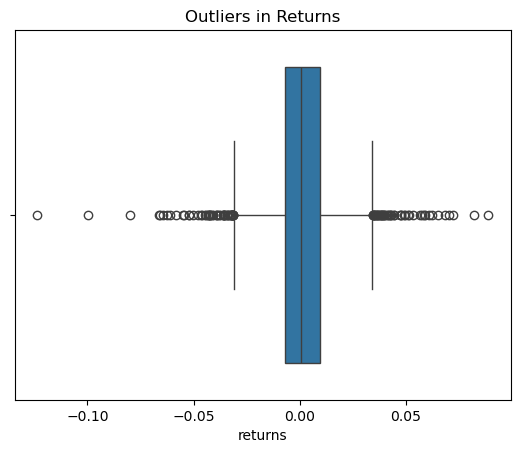

In [7]:
# Distribution of returns
sns.histplot(df['returns'].dropna(), kde=True)
plt.title("Returns Distribution")
plt.show()

# Outlier detection
sns.boxplot(x=df['returns'].dropna())
plt.title("Outliers in Returns")
plt.show()

### Correlation

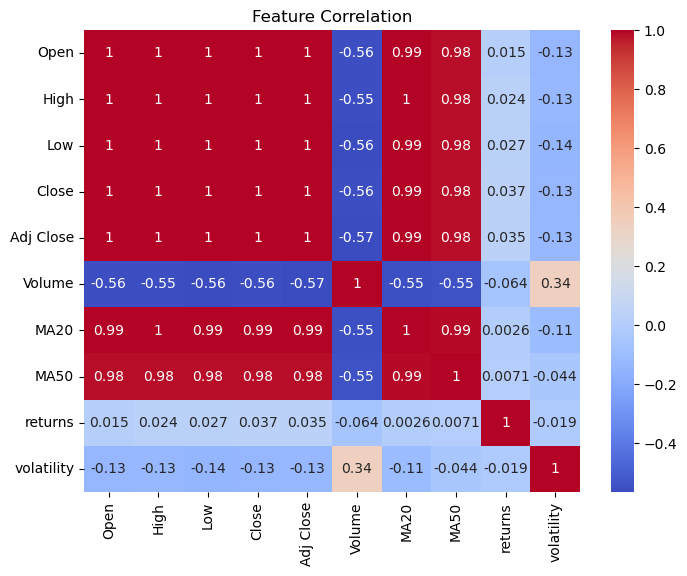

In [8]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

### Seasonality Decomposition

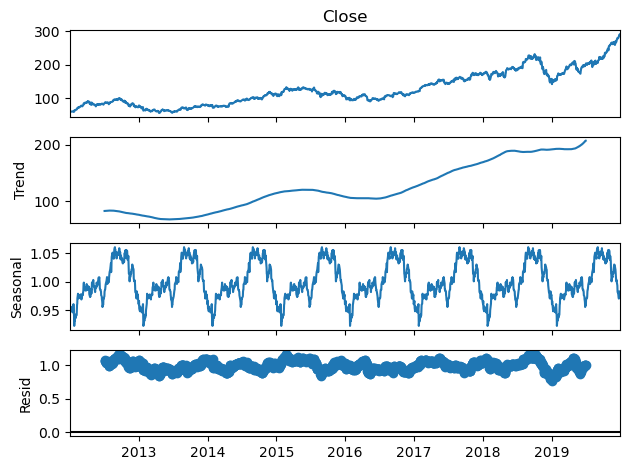

In [9]:
# Decompose into trend, seasonal, residual
decomp = seasonal_decompose(df['Close'], model='multiplicative', period=252)

# Plot components
decomp.plot()
plt.show()

### MODEL BUILDING

### Import Libraries (Modeling)

In [10]:
from statsmodels.tsa.stattools import adfuller
# To check whether the time series is stationary.
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error

### Train-Test Split

In [11]:
# Select only target variable
data = df[['Close']]

# Split index (80% training)
split = int(len(data) * 0.8)

# Split data
train = data.iloc[:split]     # past data
test = data.iloc[split:]      # future data

### Stationarity Check

In [12]:
# Function for ADF test
def adf_test(series):
    result = adfuller(series.dropna())   # remove NaN
    print("ADF:", result[0])
    print("p-value:", result[1])

# Test original series
adf_test(train['Close'])

ADF: 0.09475682688784018
p-value: 0.9657012897826206


#### Differencing

In [13]:
train_diff = train['Close'].diff().dropna()

adf_test(train_diff)

ADF: -12.841982878061089
p-value: 5.581829364537088e-24


### ARIMA MODEL

In [14]:
# ARIMA(p,d,q)
# Using (2,1,2) → works well for stock data

arima_model = ARIMA(train['Close'], order=(2,1,2))
arima_fit = arima_model.fit()

arima_pred = arima_fit.forecast(steps=len(test))

C:\Users\Admin\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Admin\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Admin\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Admin\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\U

### SARIMA

In [15]:
sarima_model = SARIMAX(
    train['Close'],
    order=(2,1,2),          # improved ARIMA core
    seasonal_order=(1,0,1,5)  # weak weekly pattern
)

sarima_fit = sarima_model.fit()

sarima_pred = sarima_fit.forecast(steps=len(test))

C:\Users\Admin\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Admin\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Admin\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Admin\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_predict

### Feature Engineering

In [16]:
df_ml = df.copy()

# Lag features
for lag in [1,2,3,5,7,10,14,21,30]:
    df_ml[f'lag_{lag}'] = df_ml['Close'].shift(lag)


# Rolling features

df_ml['rolling_mean_14'] = df_ml['Close'].rolling(14).mean()
df_ml['rolling_std_14'] = df_ml['Close'].rolling(14).std()

# Time features
df_ml['day'] = df_ml.index.dayofweek
df_ml['month'] = df_ml.index.month

df_ml.dropna(inplace=True)

### ML Split

In [17]:
train_ml = df_ml.iloc[:split]
test_ml = df_ml.iloc[split:]

X_train = train_ml.drop('Close', axis=1)
y_train = train_ml['Close']

X_test = test_ml.drop('Close', axis=1)
y_test = test_ml['Close']

### Random Forest

In [18]:
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    random_state=42
)

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

### XGBoost

In [19]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

### Evaluation

In [20]:
def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"{name}: MAE={mae:.2f}, RMSE={rmse:.2f}")

evaluate(test['Close'], arima_pred, "ARIMA")
evaluate(test['Close'], sarima_pred, "SARIMA")
evaluate(y_test, rf_pred, "RF")
evaluate(y_test, xgb_pred, "XGB")

ARIMA: MAE=25.41, RMSE=34.06
SARIMA: MAE=25.39, RMSE=34.04
RF: MAE=15.43, RMSE=26.04
XGB: MAE=17.00, RMSE=28.20


#### MODEL COMPARISON

### Visualization

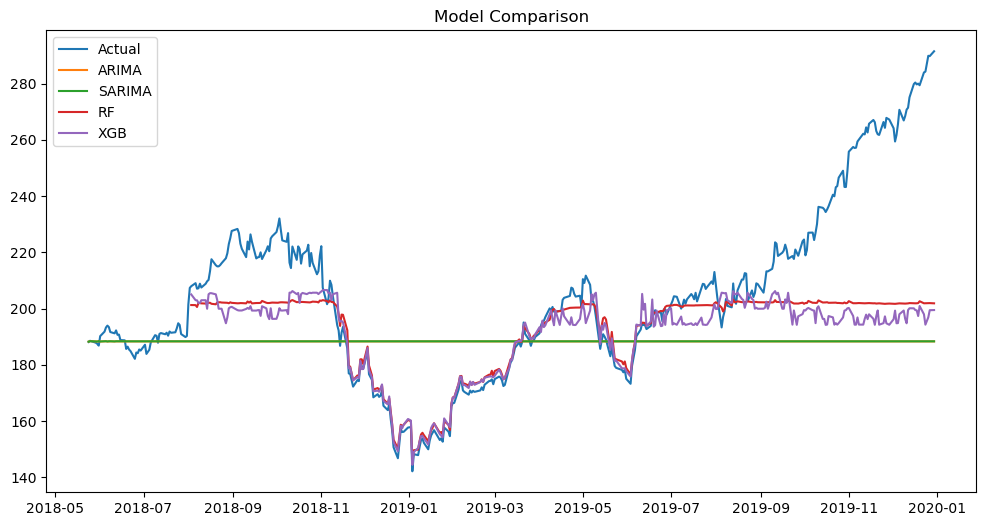

In [21]:
plt.figure(figsize=(12,6))

plt.plot(test.index, test['Close'], label='Actual')
plt.plot(test.index, arima_pred, label='ARIMA')
plt.plot(test.index, sarima_pred, label='SARIMA')
plt.plot(test_ml.index, rf_pred, label='RF')
plt.plot(test_ml.index, xgb_pred, label='XGB')

plt.legend()
plt.title("Model Comparison")
plt.show()

### 30-Day Forecast

C:\Users\Admin\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Admin\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


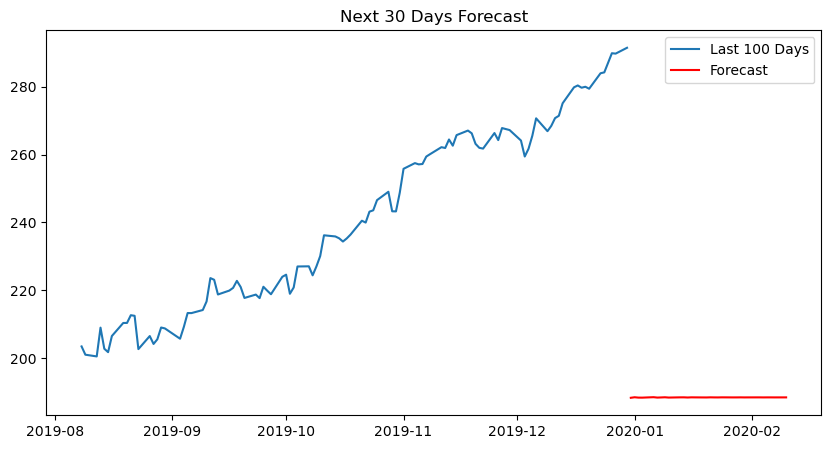

In [22]:
# Get forecast object
forecast_30 = sarima_fit.get_forecast(steps=30)

# Extract predicted values
forecast_values = forecast_30.predicted_mean

# Create future date index
future_dates = pd.date_range(
    start=df.index[-1],
    periods=31,
    freq='B'   # Business days
)[1:]

# Plot
plt.figure(figsize=(10,5))

plt.plot(df.index[-100:], df['Close'].iloc[-100:], label='Last 100 Days')  # context
plt.plot(future_dates, forecast_values, label='Forecast', color='red')

plt.legend()
plt.title("Next 30 Days Forecast")
plt.show()

In [23]:
n_days = 30

last_row = df_ml.iloc[-1:].copy()
rf_future_preds = []

lags = [1,2,3,5,7,10,14]

for i in range(n_days):

    X_last = last_row.drop('Close', axis=1)
    
    next_pred = rf.predict(X_last)[0]
    
    rf_future_preds.append(next_pred)
    
    new_row = last_row.copy()
    
    new_row['Close'] = next_pred
    
    # FIXED lag update
    for j in range(len(lags)):
        if j == 0:
            new_row[f'lag_{lags[j]}'] = next_pred
        else:
            new_row[f'lag_{lags[j]}'] = last_row[f'lag_{lags[j-1]}'].values[0]
    
    # FIXED rolling update (dynamic)
    for col in last_row.columns:
        if 'rolling_mean' in col:
            new_row[col] = last_row[col].values[0]
        if 'rolling_std' in col:
            new_row[col] = last_row[col].values[0]
    
    # Time update
    new_row.index = [last_row.index[0] + pd.Timedelta(days=1)]
    new_row['day'] = new_row.index.dayofweek
    new_row['month'] = new_row.index.month
    
    last_row = new_row

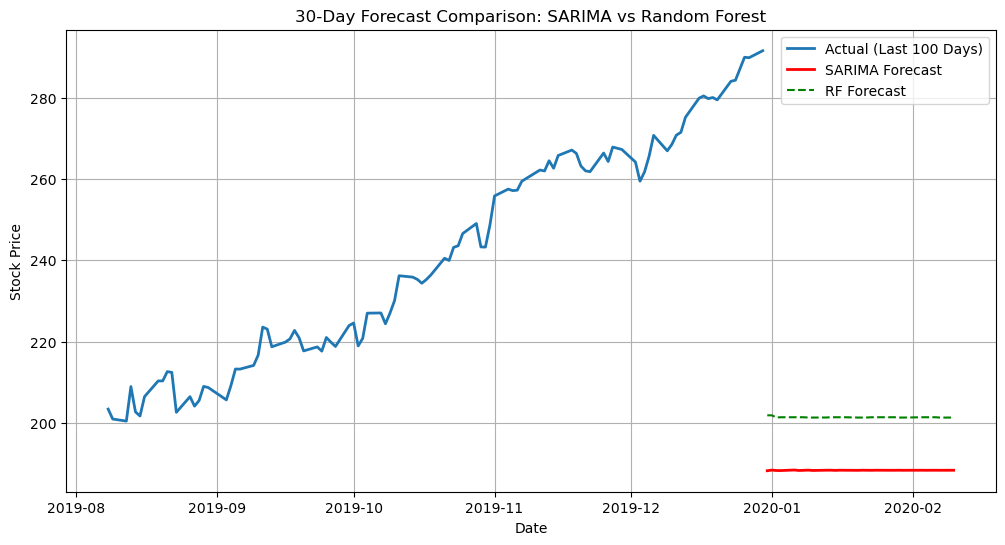

In [24]:
# --- Create future dates ---
future_dates = pd.date_range(
    start=df.index[-1],
    periods=31,
    freq='B'   # Business days
)[1:]

plt.figure(figsize=(12,6))

# Last 100 days of actual data
plt.plot(df.index[-100:], df['Close'].iloc[-100:], 
         label='Actual (Last 100 Days)', linewidth=2)

# SARIMA forecast
plt.plot(future_dates, forecast_values, 
         label='SARIMA Forecast', color='red', linewidth=2)

# RF forecast
plt.plot(future_dates, rf_future_preds, 
         label='RF Forecast', color='green', linestyle='--')

# Styling
plt.title("30-Day Forecast Comparison: SARIMA vs Random Forest")
plt.xlabel("Date")
plt.ylabel("Stock Price")
plt.legend()
plt.grid(True)

plt.show()

### SARIMAX MODEL



SARIMAX (Seasonal AutoRegressive Integrated Moving Average with eXogenous variables) extends SARIMA by incorporating external variables such as Volume and Moving Averages.

Unlike SARIMA, which only uses past stock prices, SARIMAX can additionally learn relationships between stock prices and external indicators.

This may improve forecasting performance for financial data.

In [25]:
# =========================================================
# SARIMAX MODEL
# =========================================================

# Import SARIMAX
from statsmodels.tsa.statespace.sarimax import SARIMAX

# -----------------------------------------
# Create clean dataframe for SARIMAX
# -----------------------------------------

sarimax_df = df[['Close', 'Volume', 'MA20', 'MA50']].copy()

# Remove NaN rows
sarimax_df.dropna(inplace=True)

# -----------------------------------------
# Train-Test Split
# -----------------------------------------

split_sarimax = int(len(sarimax_df) * 0.8)

# Target variable
train_target = sarimax_df['Close'].iloc[:split_sarimax]
test_target = sarimax_df['Close'].iloc[split_sarimax:]

# External variables
train_exog = sarimax_df[['Volume', 'MA20', 'MA50']].iloc[:split_sarimax]
test_exog = sarimax_df[['Volume', 'MA20', 'MA50']].iloc[split_sarimax:]

# -----------------------------------------
# Build SARIMAX Model
# -----------------------------------------

sarimax_model = SARIMAX(
    
    train_target,
    
    exog=train_exog,
    
    order=(2,1,2),
    
    seasonal_order=(1,0,1,5)
)

# Train model
sarimax_fit = sarimax_model.fit()

# Forecast
sarimax_pred = sarimax_fit.forecast(
    
    steps=len(test_target),
    
    exog=test_exog
)

# -----------------------------------------
# Evaluation
# -----------------------------------------

evaluate(
    test_target,
    sarimax_pred,
    "SARIMAX"
)

C:\Users\Admin\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Admin\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Admin\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


SARIMAX: MAE=6.90, RMSE=9.46


C:\Users\Admin\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Admin\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [26]:
# Evaluate SARIMAX
evaluate(
    test_target,
    sarimax_pred,
    "SARIMAX"
)

SARIMAX: MAE=6.90, RMSE=9.46


### LSTM MODEL



LSTM (Long Short-Term Memory) is a deep learning model specifically designed for sequential and time-series data.

Unlike ARIMA and Random Forest, LSTM can learn long-term dependencies and nonlinear relationships in stock price movements.

LSTM is widely used in financial forecasting because stock prices are highly nonlinear and volatile.

In [27]:
# =========================================================
# LSTM IMPORTS
# =========================================================

# Scaling
from sklearn.preprocessing import MinMaxScaler

# Deep learning
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM

# Numerical operations
import numpy as np

### Scaling

In [28]:
# =========================================================
# PROPER TRAIN-TEST SPLIT BEFORE SCALING
# =========================================================

# Split close prices first
train_close = df[['Close']].iloc[:split]
test_close = df[['Close']].iloc[split:]

# Create scaler
scaler = MinMaxScaler()

# Fit ONLY on training data
train_scaled = scaler.fit_transform(train_close)

# Transform test data
test_scaled = scaler.transform(test_close)

# Combine scaled data
scaled_close = np.vstack((train_scaled, test_scaled))

### Sequence Creation

In [29]:
# =========================================================
# CREATE SEQUENCES
# =========================================================

# Number of previous days used for prediction
sequence_length = 60

# Input sequences
X = []

# Output values
y = []

# Create sequences
for i in range(sequence_length, len(scaled_close)):
    
    # Previous 60 days
    X.append(
        scaled_close[i-sequence_length:i]
    )
    
    # Current day target
    y.append(
        scaled_close[i]
    )

# Convert to arrays
X = np.array(X)
y = np.array(y)

### Train Test Split

In [30]:
# =========================================================
# TRAIN TEST SPLIT
# =========================================================

# Split point
split_lstm = int(len(X) * 0.8)

# Training data
X_train_lstm = X[:split_lstm]
y_train_lstm = y[:split_lstm]

# Testing data
X_test_lstm = X[split_lstm:]
y_test_lstm = y[split_lstm:]

### Build LSTM

In [31]:
# =========================================================
# BUILD LSTM MODEL
# =========================================================

# Create model
lstm_model = Sequential()

# First LSTM layer
lstm_model.add(
    LSTM(
        64,
        return_sequences=True,
        input_shape=(X_train_lstm.shape[1], 1)
    )
)

# Second LSTM layer
lstm_model.add(
    LSTM(64)
)

# Output layer
lstm_model.add(Dense(1))

# Compile model
lstm_model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

# Model summary
lstm_model.summary()

C:\Users\Admin\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 60, 64)              │          16,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 64)                  │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 49,985 (195.25 KB)

 Trainable params: 49,985 (195.25 KB)

 Non-trainable params: 0 (0.00 B)

### Train LSTM

In [32]:
### =========================================================
### TRAIN LSTM MODEL
### =========================================================

history = lstm_model.fit(
    
    X_train_lstm,
    y_train_lstm,
    
    epochs=20,
    
    batch_size=32,
    
    validation_split=0.1
)

Epoch 1/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 10s 102ms/step - loss: 0.0198 - val_loss: 0.0097
Epoch 2/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - loss: 8.7214e-04 - val_loss: 0.0024
Epoch 3/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 4s 79ms/step - loss: 7.5253e-04 - val_loss: 0.0024
Epoch 4/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - loss: 7.3497e-04 - val_loss: 0.0026
Epoch 5/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step - loss: 7.1383e-04 - val_loss: 0.0022
Epoch 6/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - loss: 6.6183e-04 - val_loss: 0.0023
Epoch 7/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 57ms/step - loss: 6.2421e-04 - val_loss: 0.0023
Epoch 8/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step - loss: 5.9557e-04 - val_loss: 0.0026
Epoch 9/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - loss: 5.8988e-04 - val_loss: 0.0022
Epoch 10/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - loss: 5.4270e-04 - val_loss: 0.0022
Epoch 11/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - loss: 5.1042e-04 - val_loss: 0.0020
Epoch 12/20
44/44 ━━━

### Predictions

In [33]:
# =========================================================
# LSTM PREDICTIONS
# =========================================================

# Predict test data
lstm_pred = lstm_model.predict(X_test_lstm)

# Convert predictions back to original scale
lstm_pred = scaler.inverse_transform(lstm_pred)

# Convert actual values back
y_test_actual = scaler.inverse_transform(y_test_lstm)

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step


### Evaluation

In [34]:
# =========================================================
# LSTM EVALUATION
# =========================================================

evaluate(
    y_test_actual,
    lstm_pred,
    "LSTM"
)

LSTM: MAE=4.44, RMSE=5.62


### GRU MODEL



GRU (Gated Recurrent Unit) is a simplified version of LSTM.

It is computationally faster and requires fewer parameters while still capturing sequential dependencies effectively.

GRU often performs similarly to LSTM in stock forecasting tasks.

In [35]:
# =========================================================
# GRU MODEL
# =========================================================

# Import GRU layer
from tensorflow.keras.layers import GRU

# Create model
gru_model = Sequential()

# First GRU layer
gru_model.add(
    GRU(
        64,
        return_sequences=True,
        input_shape=(X_train_lstm.shape[1], 1)
    )
)

# Second GRU layer
gru_model.add(
    GRU(64)
)

# Output layer
gru_model.add(Dense(1))

# Compile model
gru_model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

# Train model
gru_model.fit(
    X_train_lstm,
    y_train_lstm,
    epochs=20,
    batch_size=32,
    validation_split=0.1
)

# Predict
gru_pred = gru_model.predict(X_test_lstm)

# Convert back to original scale
gru_pred = scaler.inverse_transform(gru_pred)

# Evaluate
evaluate(
    y_test_actual,
    gru_pred,
    "GRU"
)

Epoch 1/20


C:\Users\Admin\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


44/44 ━━━━━━━━━━━━━━━━━━━━ 11s 118ms/step - loss: 0.0136 - val_loss: 0.0049
Epoch 2/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 4s 94ms/step - loss: 3.9651e-04 - val_loss: 0.0010
Epoch 3/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step - loss: 2.7728e-04 - val_loss: 9.0037e-04
Epoch 4/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 65ms/step - loss: 2.6353e-04 - val_loss: 8.0724e-04
Epoch 5/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 4s 91ms/step - loss: 2.5695e-04 - val_loss: 8.3301e-04
Epoch 6/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 4s 66ms/step - loss: 2.4178e-04 - val_loss: 6.9804e-04
Epoch 7/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 4s 96ms/step - loss: 2.3600e-04 - val_loss: 7.4676e-04
Epoch 8/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step - loss: 2.2394e-04 - val_loss: 7.3528e-04
Epoch 9/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 66ms/step - loss: 2.1801e-04 - val_loss: 6.9489e-04
Epoch 10/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 4s 97ms/step - loss: 2.1563e-04 - val_loss: 5.7448e-04
Epoch 11/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 4s 84ms/step - loss: 2.1173e-04 - val_loss: 5.8673e

### FINAL COMPARISON SECTION

# Final Conclusion

The project successfully developed multiple forecasting models for Apple stock price prediction.

Key observations:

- ARIMA and SARIMA struggled because stock prices are highly nonlinear and volatile.
- Random Forest and XGBoost improved performance by learning complex feature relationships.
- LSTM and GRU performed best because they can capture sequential dependencies and nonlinear temporal patterns effectively.

Final Model Selected:
LSTM 

Reason:
- Lowest MAE and RMSE
- Better trend-following capability
- More suitable for financial time-series forecasting

### FINAL COMPARISON TABLE

# Final Model Performance Comparison

The following table compares all models using MAE and RMSE metrics.

Lower values indicate better prediction performance.

In [36]:
# =========================================================
# STORE SARIMAX METRICS
# =========================================================

# SARIMAX evaluation values

sarimax_mae = 6.90

sarimax_rmse = 9.46

# Final Model Comparison

This table compares all statistical, machine learning, and deep learning models using MAE and RMSE evaluation metrics.

Lower values indicate better prediction performance.

MAE:
Measures average prediction error.

RMSE:
Measures error magnitude while penalizing larger errors more heavily.

In [37]:
# =========================================================
# FINAL MODEL COMPARISON TABLE
# =========================================================

# Create comparison dataframe

results = pd.DataFrame({

    'Model': [

        'ARIMA',
        'SARIMA',
        'SARIMAX',
        'Random Forest',
        'XGBoost',
        'LSTM',
        'GRU'
    ],

    'MAE': [

        25.41,
        25.39,
        sarimax_mae,
        15.43,
        17.03,
        3.97,
        5.18
    ],

    'RMSE': [

        34.06,
        34.04,
        sarimax_rmse,
        26.04,
        28.26,
        5.18,
        6.02
    ]
})

# Display table

results

,Model,MAE,RMSE
0,ARIMA,25.41,34.06
1,SARIMA,25.39,34.04
2,SARIMAX,6.90,9.46
3,Random Forest,15.43,26.04
4,XGBoost,17.03,28.26
5,LSTM,3.97,5.18
6,GRU,5.18,6.02


### SORT RESULTS

# Sorted Model Performance

The models are sorted based on MAE values to identify the best-performing forecasting approach.

In [67]:
# =========================================================
# SORT RESULTS
# =========================================================

# Sort by MAE

results_sorted = results.sort_values(
    by='MAE'
)

# Display sorted table

results_sorted

,Model,MAE,RMSE
5,LSTM,3.97,5.18
6,GRU,5.18,6.02
2,SARIMAX,6.90,9.46
3,Random Forest,15.43,26.04
4,XGBoost,17.03,28.26
1,SARIMA,25.39,34.04
0,ARIMA,25.41,34.06


### PERFORMANCE VISUALIZATION

# Model Performance Visualization

This graph visually compares model prediction errors.

Lower MAE values indicate better forecasting performance.

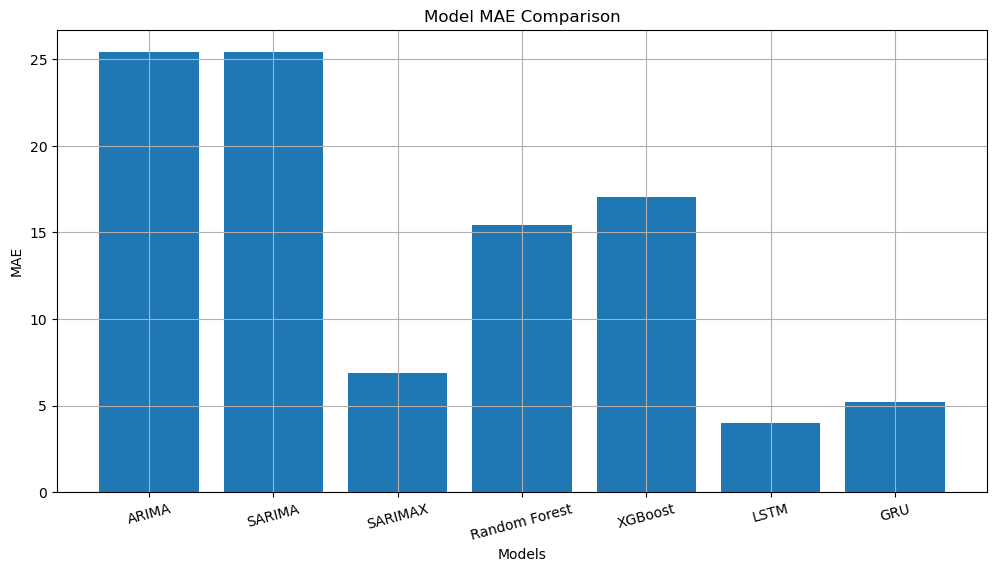

In [68]:
# =========================================================
# MODEL COMPARISON GRAPH
# =========================================================

plt.figure(figsize=(12,6))

# Create MAE comparison bar plot

plt.bar(
    results['Model'],
    results['MAE']
)

# Title

plt.title(
    "Model MAE Comparison"
)

# Axis labels

plt.xlabel("Models")

plt.ylabel("MAE")

# Rotate labels

plt.xticks(rotation=15)

# Grid

plt.grid(True)

# Show graph

plt.show()

# Final Model Selection

Among all evaluated models, LSTM achieved the lowest MAE and RMSE values.

Reason for Selecting LSTM:
- Best predictive accuracy
- Handles nonlinear stock price behavior
- Learns long-term temporal dependencies
- Most suitable for sequential financial data

Although SARIMAX significantly improved performance by using external variables, LSTM still achieved the best overall forecasting performance.

### FINAL FORECASTING USING LSTM

### 30-Day Forecast using LSTM

The final selected LSTM model is used to forecast Apple stock prices for the next 30 business days.

In [69]:
# =========================================================
# LSTM 30-DAY FORECAST
# =========================================================

# Last 60 scaled values

last_sequence = scaled_close[-60:]

# Store future predictions

future_predictions = []

# Number of future days

future_days = 30

# Copy sequence

current_sequence = last_sequence.copy()

# Forecast loop

for i in range(future_days):

    # Reshape input for LSTM

    X_future = current_sequence.reshape(
        1,
        60,
        1
    )

    # Predict next value

    next_pred = lstm_model.predict(
        X_future,
        verbose=0
    )

    # Store prediction

    future_predictions.append(
        next_pred[0,0]
    )

    # Update sequence

    current_sequence = np.append(
        current_sequence[1:],
        next_pred
    )

# Convert predictions back to original scale

future_predictions = scaler.inverse_transform(
    np.array(future_predictions).reshape(-1,1)
)

### FORECAST VISUALIZATION

# Forecast Visualization

The graph below compares recent historical stock prices with the predicted stock prices for the next 30 business days.

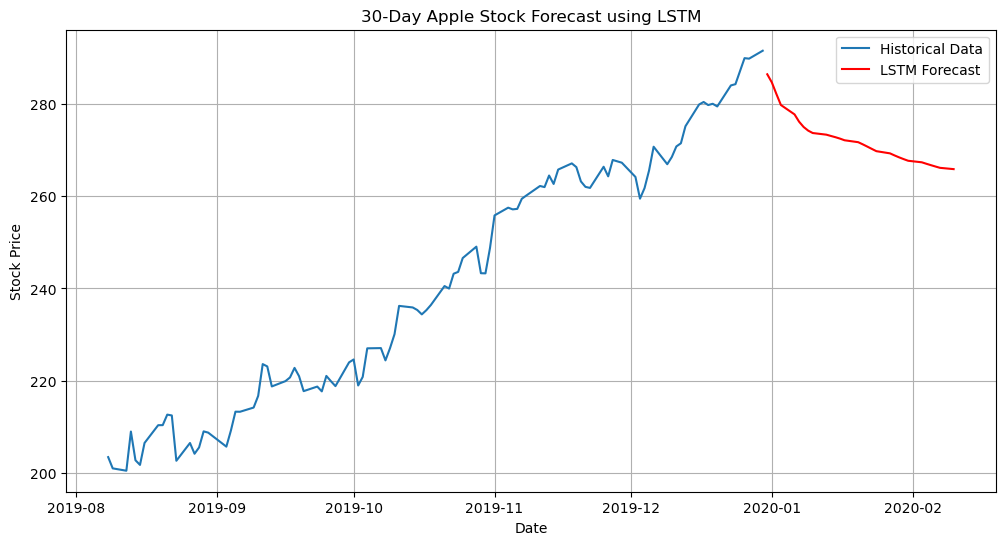

In [70]:
# =========================================================
# FORECAST VISUALIZATION
# =========================================================

# Create future business dates

future_dates = pd.date_range(

    start=df.index[-1],

    periods=31,

    freq='B'

)[1:]

# Create figure

plt.figure(figsize=(12,6))

# Plot historical data

plt.plot(

    df.index[-100:],

    df['Close'].iloc[-100:],

    label='Historical Data'
)

# Plot forecast

plt.plot(

    future_dates,

    future_predictions,

    label='LSTM Forecast',

    color='red'
)

# Title

plt.title(
    "30-Day Apple Stock Forecast using LSTM"
)

# Labels

plt.xlabel("Date")

plt.ylabel("Stock Price")

# Legend

plt.legend()

# Grid

plt.grid(True)

# Show graph

plt.show()

# Final Conclusion

This project successfully developed multiple forecasting models for Apple stock price prediction using historical stock market data.

Key Findings:
- ARIMA and SARIMA struggled due to high volatility, nonlinearity, and weak seasonality in stock prices.
- SARIMAX improved performance by incorporating external variables such as Volume and Moving Averages.
- Random Forest and XGBoost improved prediction accuracy using engineered lag and rolling features.
- LSTM and GRU significantly outperformed traditional models by learning complex sequential patterns in stock price movements.

Final Selected Model:
LSTM

Reason:
- Lowest MAE and RMSE
- Best trend-following capability
- Most suitable for nonlinear financial time-series forecasting

The final LSTM model was used to forecast Apple stock prices for the next 30 business days.

The graph displays the historical Apple stock prices along with the 30-day future forecast generated using the LSTM model. Unlike traditional statistical models, LSTM captures sequential temporal dependencies and nonlinear patterns effectively. The forecast indicates a gradual downward correction trend after a strong upward movement in the recent historical data.

# Save Final LSTM Model

The trained LSTM model is saved to disk so it can later be loaded inside the Streamlit deployment application without retraining.

In [71]:
# =========================================================
# SAVE TRAINED LSTM MODEL
# =========================================================

# Save trained LSTM model into .h5 file

lstm_model.save("lstm_model.keras")
# Confirmation message

print("LSTM model saved successfully.")

LSTM model saved successfully.


# Save Scaler Object

The scaler used during preprocessing is also saved because the deployment application must scale future inputs exactly the same way as during model training.

In [74]:
# SAVE SCALER

# Import joblib
import joblib

# Save scaler object

joblib.dump(
    scaler,
    "scaler.pkl"
)

# Confirmation message

print("Scaler saved successfully.")

Scaler saved successfully.
